<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;"> NFL Big Bowl 🏟️📊| Exploring Players.csv </p>

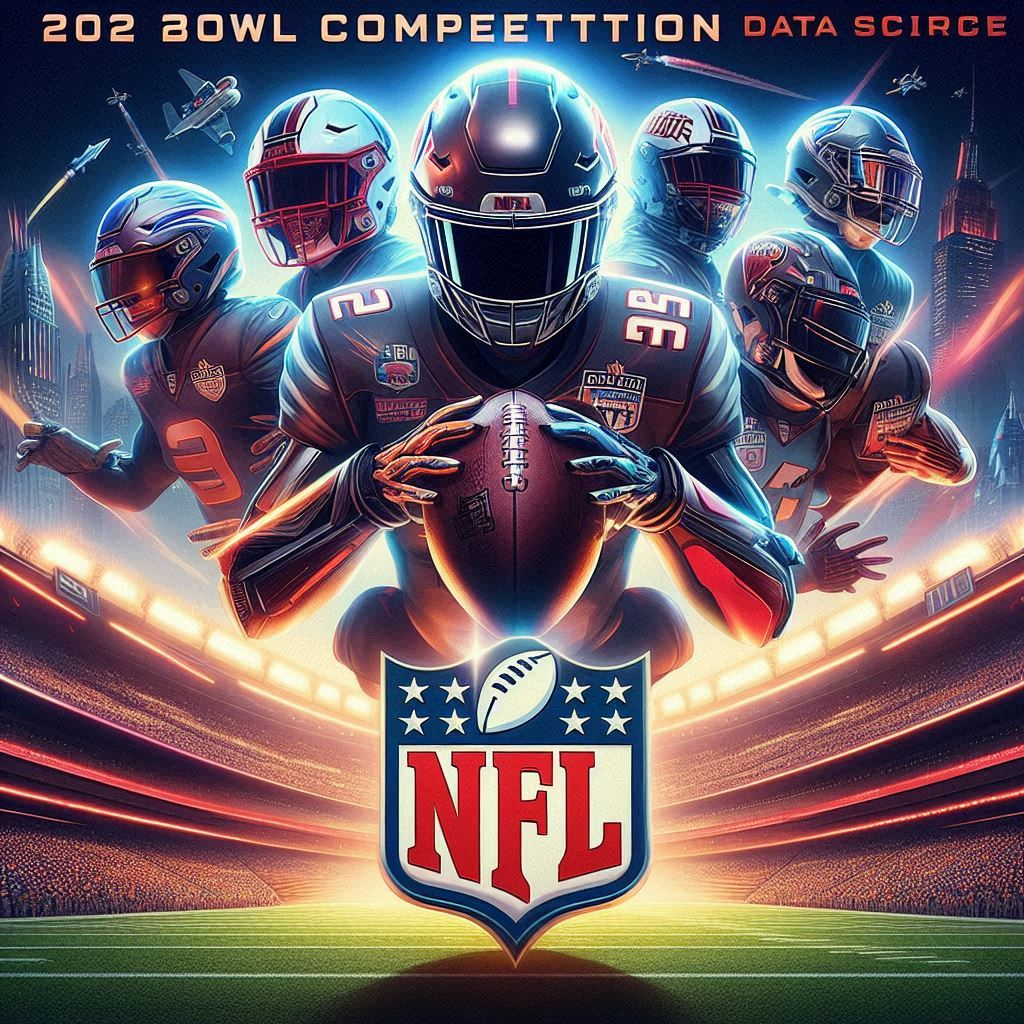

<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;"> About The Dataset</p>

| Attribute      | Description                                      | Data Type |
|----------------|--------------------------------------------------|-----------|
| **nflId**      | Player identification number, unique across players | Numeric   |
| **height**     | Player height                                    | Text      |
| **weight**     | Player weight                                    | Numeric   |
| **birthDate**  | Date of birth (YYYY-MM-DD)                       | Text      |
| **collegeName**| Player college                                   | Text      |
| **position**   | Official player position                         | Text      |
| **displayName**| Player name                                      | Text      |


<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;"> Importing the libraries  </p>

# ```I have already uploaded 2 more notebooks exploring the dataset for better understanding you can also check them :)```
## **PART_1**  ==> [🏈 Games Insightful Analysis: Players in Action 📊](https://www.kaggle.com/code/arshmankhalid/games-insightful-analysis-players-in-action)

## PART_2 ==> [Big Bowl EDA: Crushing Player Stats! 📈💥](https://www.kaggle.com/code/arshmankhalid/big-bowl-eda-crushing-player-stats))

In [ ]:
#  Importing the basic libraries 
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from IPython.display import display, HTML
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'iframe'
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/kaggle/input/nfl-big-data-bowl-2025/players.csv")

In [ ]:
df.info()

df.isnull().sum()

<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;"> Quick Overview Of The Data </p>

In [ ]:
def styled_heading(text, background_color='#e81138', text_color='white'):
    return f"""
    <p style="
        background-color: {background_color};
        font-family: Pacifico, cursive;
        font-size: 150%;
        color: {text_color};
        text-align: center;
        border-radius: 10px;
        padding: 10px;
        font-weight: normal;
        box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);
        width: fit-content;
        margin: 0 auto;
    ">
        {text}
    </p>
    """

def style_table(df):
    styled_df = df.style.set_table_styles([
        {"selector": "th", "props": [("color", "white"), ("background-color", "#ff6f61")]},
        {"selector": "td", "props": [("background-color", "#e3f2fd"), ("color", "#333333")]}  # Light blue for table cells
    ]).set_properties(**{"text-align": "center"}).hide(axis="index")
    return styled_df.to_html()

def print_dataset_analysis(train_dataset, n_top=5, heading_color='#ff6f61', text_color='white'):
    train_heading = styled_heading(f"📊 Basic Overview of Data", heading_color, text_color)
    display(HTML(train_heading))
    display(HTML(style_table(train_dataset.head(n_top))))

    summary_heading = styled_heading("🔍 Data Summary", heading_color, text_color)
    display(HTML(summary_heading))
    display(HTML(style_table(train_dataset.describe())))

    null_heading = styled_heading("🚫 Null Values in Data", heading_color, text_color)
    train_null_count = train_dataset.isnull().sum()
    display(HTML(null_heading))
    if train_null_count.sum() == 0:
        display(HTML("<p>No null values in the dataset.</p>"))
    else:
        display(HTML("<h3>Null Values:</h3>"))
        display(HTML(style_table(train_null_count[train_null_count > 0].to_frame())))
        display(HTML("<p>These are the null values.</p>"))

    duplicate_heading = styled_heading("♻️ Duplicate Values in Data", heading_color, text_color)
    train_duplicates = train_dataset.duplicated().sum()
    display(HTML(duplicate_heading))
    display(HTML("<h3>Duplicates:</h3>"))
    display(HTML(f"<p>{train_duplicates} duplicate rows found.</p>"))

    shape_heading = styled_heading("📏 Data Shape", heading_color, text_color)
    display(HTML(shape_heading))
    display(HTML("<h3>Shape:</h3>"))
    display(HTML(f"<p>Rows: {train_dataset.shape[0]}, Columns: {train_dataset.shape[1]}</p>"))

def print_unique_values(train_dataset, heading_color='#ff6f61', text_color='white'):
    unique_values_heading = styled_heading("🔢 Unique Values in Data", heading_color, text_color)
    display(HTML(unique_values_heading))
    unique_values_table = pd.DataFrame({
        'Column Name': train_dataset.columns,
        'Data Type': [train_dataset[col].dtype for col in train_dataset.columns],
        'Unique Values': [', '.join(map(str, train_dataset[col].unique()[:7])) for col in train_dataset.columns]
    })
    display(HTML(style_table(unique_values_table)))

In [ ]:
print_dataset_analysis(df , n_top=5, heading_color='#1f2f7f', text_color='white')
print_unique_values(df , heading_color='#1f2f7f', text_color='white')


<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;"> Feature Engineering</p>

In [ ]:
# Function to convert height (e.g., "6-4") to inches
def height_to_inches(height):
    try:
        feet, inches = map(int, height.split('-'))
        return feet * 12 + inches
    except:
        return None

df['height_inches'] = df['height'].apply(height_to_inches)

# Parse birthDate into datetime and calculate age
df['birthDate'] = pd.to_datetime(df['birthDate'], errors='coerce')
df['age'] = (pd.Timestamp('now') - df['birthDate']).dt.days // 365

# Calculating BMI (weight / height² * 703 for inches and pounds)
df['BMI'] = (df['weight'] / (df['height_inches'] ** 2)) * 703

# Encoding positions as categorical variables
df['position_encoded'] = df['position'].astype('category').cat.codes

# Encoding college names as categorical variables
df['college_encoded'] = df['collegeName'].astype('category').cat.codes

# Droping irrelevant or redundant columns if needed (e.g., `height` after creating `height_inches`)
df.drop(columns=['height'], inplace=True)

# Preview the preprocessed dataset
print(df)

<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;"> 0.1| Distribution Of The Data</p>

In [ ]:
# Continuous features
cols = ['weight', 'height_inches', 'BMI', 'age']
for col in cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Insights from the Graphs

1. **Weight**: Bimodal distribution (~200 lbs, ~300 lbs). Suggests two groups, possibly by role or specialization.
2. **Height**: Normally distributed (~72–75 inches). Outliers might indicate unique player roles or traits.
3. **BMI**: Slight right skew (~25–30), typical for athletes. Higher BMI could correspond to strength-based roles.
4. **Age**: Right-skewed (~20–25 years). Highlights a younger player base, with older players likely contributing experiened players.


<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;"> 0.2| Position Distribution</p>

In [ ]:
# Position counts
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='position', order=df['position'].value_counts().index, palette='viridis')
plt.title('Position Distribution')
plt.show()

# College counts (top 10)
top_colleges = df['collegeName'].value_counts().head(10)
top_colleges.plot(kind='barh', figsize=(8, 6), color='orange')
plt.title('Top 10 Colleges')
plt.xlabel('Number of Players')
plt.show()


# Insights from the Graphs

## 1. **Position Distribution**
   - **Most Common Positions**: Wide Receiver (WR) and Cornerback (CB) dominate the count.
   - **Least Common Positions**: Fullback (FB), Linebacker (LB), and Defensive Back (DB) are the least represented.
   - **Insights**:
     - Skill-based positions (e.g., WR, CB, RB) are more prevalent, indicating a potential focus on offensive/defensive agility.
     - Lesser-represented positions (e.g., FB, LB) may offer niche opportunities for specialized strategies.

## 2. **Top 10 Colleges**
   - **Leading Colleges**: Alabama and Ohio State produce the highest number of players.
   - **Other Notable Schools**: Georgia, Louisiana State, and Michigan contribute significantly.
   - **Insights**:
     - Recruitment pipelines are strongest in top-performing colleges. Leveraging data from these schools could help in predicting player success.
     - A focus on players from these institutions may align with established talent pathways.

## Strategy Suggestions
1. **Position Analysis**:
   - Develop specialized training or scouting strategies for skill-dominant positions (e.g., WR, CB).
   - Explore value in underrepresented positions to identify overlooked talent.

2. **College Data Utilization**:
   - Prioritize scouting from top-producing colleges (e.g., Alabama, Ohio State).
   - Analyze performance trends by college to enhance recruitment models.


<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;">0.3|  Height vs Weight by Position</p>

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='height_inches', y='weight', hue='position', palette='deep', alpha=0.7)
plt.title('Height vs Weight by Position')
plt.xlabel('Height (inches)')
plt.ylabel('Weight (lbs)')
plt.show()


## Insights from "Height vs Weight by Position"

- **Taller players** (≥75 inches) tend to weigh more (≥300 lbs), while **shorter players** (≤70 inches) usually weigh below 200 lbs.
- **Quarterbacks (QB)** and **Wide Receivers (WR)** are lighter (180-220 lbs) and average height (70-75 inches).
- **Defensive Tackles (DT)** and **Guards (G)** are the heaviest (≥300 lbs) and taller (≥73 inches).
- **Running Backs (RB)** and **Cornerbacks (CB)** are shorter (68-73 inches) and weigh around 200-230 lbs.
- **Linebackers (ILB/OLB)** and **Tight Ends (TE)** balance height (72-76 inches) and weight (220-260 lbs).
- Outliers: A few **Tackles (T)** and **Defensive Ends (DE)** exceed 80 inches and 350 lbs.
- **Speed positions** (CB, WR) are compact, while **physical roles** (DT, G) favor bulk.

### Conclusion:
Player physiques are highly specialized, reflecting the physical and strategic demands of their positions.


<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;"> 0.4 | Age vs BMI by Position </p>

In [ ]:
# Age distribution by position
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='position', y='age', palette='muted')
plt.title('Age Distribution by Position')
plt.xticks(rotation=45)
plt.show()

# Age vs BMI
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='BMI', hue='position', palette='viridis', alpha=0.7)
plt.title('Age vs BMI by Position')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()


## Insights from "Age Distribution by Position"

- Most player ages cluster around **25-30 years** across all positions.
- **Quarterbacks (QB)** show the widest age range, with some players over **45 years**.
- **Linebackers (LB)** and **Fullbacks (FB)** have narrower distributions, indicating younger player pools.
- **Tackles (T)** and **Guards (G)** display consistent median ages around 30 years.
- Positions like **Cornerbacks (CB)** and **Wide Receivers (WR)** skew slightly younger, reflecting the need for agility and sp- lusion:
The age range varies by position, with QB showing the most longevity, while speed-intensive roles lean younger.
 positions.


## Insights from "Age vs BMI by Position"

- **BMI Distribution**:
  - Most players have a **BMI between 25 and 40**, regardless of position.
  - **Tackles (T)**, **Guards (G)**, and **Defensive Tackles (DT)** cluster at higher BMIs (≥35), reflecting their bulkier builds.
  - Speed-focused positions like **Wide Receivers (WR)** and **Cornerbacks (CB)** tend to have lower BMIs (≤30).

- **Age Trends**:
  - Players aged **25-30 years** dominate across all BMI levels.
  - Older players (≥35 years) are rare, primarily seen in positions like **Quarterback (QB)** and some **Offensive Line (OL)** roles.

- **Position-Specific Insights**:
  - **Linebackers (LB)** and **Fullbacks (FB)** show balanced BMI ranges with younger age profiles.
  - **Quarterbacks (QB)** maintain moderate BMIs, with greater representation in the older age range (- ## Conclusion:
BMI correlates with position-specific roles, with heavier builds for linemen and lower BMIs for agile positions. Age diversity highlights the physical demands of different roles.


<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;"> 0.5 | Top 10 Colleges by Average BMI</p>

In [ ]:
top_colleges_bmi = df.groupby('collegeName')['BMI'].mean().sort_values(ascending=False).head(10)
top_colleges_bmi.plot(kind='bar', figsize=(10, 6), color='purple')
plt.title('Top 10 Colleges by Average BMI')
plt.ylabel('Average BMI')
plt.show()



### Insights from the Bar Chart: Top 10 Colleges by Average BMI

1. **Top College by Average BMI**: Regina (Canada) leads with the highest average BMI among the colleges.
2. **Close Competition**: The other colleges (North Carolina at Pembroke, Wagner, Maine, Fort Hays State, etc.) exhibit similar BMI averages, indicating a consistent trend among the top colleges.
3. **Geographical Spread**: The list includes colleges from diverse locations, showing no significant regional dominance in BMI values.
4. **BMI Range**: The average BMI values for these colleges are close to the 40-mark, suggesting a clustering of player physiques around this level among the top-ranking colleges.


<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;">0.6|  Players' Birth Year Trend</p>

In [ ]:
# Players' birth years and age trends
df['birthYear'] = df['birthDate'].dt.year
birth_year_counts = df['birthYear'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
birth_year_counts.plot(kind='line', marker='o', color='green')
plt.title('Players Birth Year Trend')
plt.xlabel('Year')
plt.ylabel('Number of Players')
plt.show()


### Insights from the Line Chart: Players' Birth Year Trend

1. **Peak Birth Years**: The number of players peaked between 1993 and 1995, indicating these years produced the most players in the dataset.
2. **Steady Growth**: From the mid-1980s to the early 1990s, there is a significant increase in the number of players, showing a growing trend in recruitment or participation.
3. **Decline Post-1995**: A sharp decline is observed after 1995, indicating fewer players born in the late 1990s are represented in the dataset.
4. **Early Years**: Minimal representation of players born before the mid-1980s, likely reflecting the age distribution in the dataset.


<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;"> 0.7 | Clustering Players by Physical Attributes</p>

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Features for clustering
cluster_features = df[['height_inches', 'weight', 'BMI']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

# KMeans Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

# Visualize clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='height_inches', y='weight', hue='cluster', palette='tab10', alpha=0.8)
plt.title('Clustering Players by Physical Attributes')
plt.xlabel('Height (inches)')
plt.ylabel('Weight (lbs)')
plt.show()

# Examine archetypes
cluster_means = df.groupby('cluster')[['height_inches', 'weight', 'BMI']].mean()
print(cluster_means)


### Insights from the Scatter Plot: Clustering Players by Physical Attributes

1. **Clustering Overview**: Players are grouped into five distinct clusters based on their height, weight, and BMI:
   - **Cluster 0 (Blue)**: Represents players with the tallest heights (above 76 inches) and the heaviest weights (above 300 lbs). This cluster corresponds to players with high BMI values, likely linemen or similar positions.
   - **Cluster 1 (Orange)**: Consists of shorter players (around 72 inches) with moderate weight (~250 lbs). They have relatively lower BMI values.
   - **Cluster 2 (Green)**: Includes players of average height (74-75 inches) and weight (~252 lbs), with BMI values hovering around 28.
   - **Cluster 3 (Red)**: Represents the shortest players (66-70 inches) with the lightest weights (below 200 lbs), indicating positions that prioritize speed and agility, such as wide receivers or running backs.
   - **Cluster 4 (Purple)**: Features taller players (76-78 inches) with higher weights (~310 lbs), showing a balance between size and weight, likely players in specialized roles.

2. **BMI Distribution**:
   - Cluster 0 has the highest BMI (38.9), suggesting a higher proportion of body mass relative to height.
   - Cluster 1 and Cluster 4 have similar BMI values (~36), indicating players in these groups maintain a proportional build.
   - Cluster 3 shows the lowest BMI (~28.1), aligning with lighter and more agile players.

3. **Height-Weight Correlation**:
   - A clear trend shows taller players generally weigh more, and this is reflected across all clusters. 
   - Outliers exist in Cluster 0 and Cluster 4, where some players exhibit exceptional height or weight.

4. **Positional Implications**:
   - The clustering may correspond to NFL player positions:
     - Cluster 0 and Cluster 4: Likely linemen or other physically demanding roles.
     - Cluster 3: Positions requiring speed and agility.
     - Cluster 1 and Cluster 2: Players in balanced roles, such as linebackers or tight ends.

5. **Distinct Gaps**:
   - The gaps between clusters suggest distinct body compositions among player roles, emphasizing the physical diversity required in the NFL.


<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;">0.8 | Average BMI by Position</p>

In [ ]:
# Average BMI by position
bmi_position = df.groupby('position')['BMI'].mean().sort_values(ascending=False)

# Plot BMI by position
plt.figure(figsize=(12, 6))
bmi_position.plot(kind='bar', color='teal')
plt.title('Average BMI by Position')
plt.ylabel('BMI')
plt.xlabel('Position')
plt.show()


### Insights from the Graph: Average BMI by Position

1. **Highest BMI by Position:**
   - Positions such as **NT (Nose Tackle)**, **DT (Defensive Tackle)**, and **G (Guard)** exhibit the highest average BMI, all exceeding 35.
   - These positions demand a larger body mass and strength to withstand and exert force in line-of-scrimmage battles.

2. **Moderate BMI by Position:**
   - Positions like **DE (Defensive End)**, **FB (Fullback)**, and **T (Tackle)** show a moderately high BMI, between 30 and 35.
   - These roles require a combination of strength and agility, balancing size with speed.

3. **Lower BMI by Position:**
   - Positions such as **WR (Wide Receiver)**, **DB (Defensive Back)**, and **CB (Cornerback)** have the lowest average BMI, generally below 25.
   - These positions emphasize speed, agility, and endurance over mass.

4. **Trend Observation:**
   - There is a clear correlation between a player's role on the field and their average BMI.
   - Players in positions requiring physical collisions and blocking tend to have higher BMI, whereas roles focused on speed and maneuverability show lower BMI.

This analysis highlights how player physiques are tailored to the demands of their respective positions in professional football.


<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;">0.9 | Positional Age Trends Over Time¶</p>

In [ ]:
# Average age by position per year
df['birthYear'] = df['birthDate'].dt.year
age_trends = df.groupby(['birthYear', 'position'])['age'].mean().reset_index()

# Plot
plt.figure(figsize=(14, 8))
sns.lineplot(data=age_trends, x='birthYear', y='age', hue='position', marker='o')
plt.title('Positional Age Trends Over Time')
plt.xlabel('Birth Year')
plt.ylabel('Average Age')
plt.show()


### Insights from the Graph: Positional Age Trends Over Time

1. **Age Decline with Birth Year:**
   - The graph shows a clear **downward trend** in average age as the birth year progresses from earlier decades to later ones.
   - Players born in earlier decades (e.g., 1970s and 1980s) are older compared to those born in more recent years (e.g., 1990s and 2000s).

2. **Positional Similarities:**
   - The average age trends across different positions (e.g., **QB, WR, LB, RB**) are relatively consistent, with only minor variations.
   - This suggests that the generational changes in age are largely uniform across all positions in the NFL.

3. **Impact of Generational Shift:**
   - The decline in age over time may indicate a generational shift towards younger players entering the league.
   - This could be attributed to the faster turnover of players, evolving physical demands, or teams prioritizing younger talent.

4. **Slight Positional Differences:**
   - While positions like **QB (Quarterback)** and **T (Tackle)** show a slightly higher average age at certain points, the overall trend aligns with the general decline.
   - Positions demanding physical endurance or agility might have younger average ages compared to strategic positions like QB.

5. **Consistency in Transition:**
   - The trendline's smoothness indicates no abrupt generational changes, signifying a gradual evolution in player demogr positional demands.


<a id="Import"></a>
# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;">0.10| Physical Attributes Comparison by Position</p>

In [ ]:
# Pairplot for physical attributes across positions
import seaborn as sns

sns.pairplot(df, vars=['height_inches', 'weight', 'BMI'], hue='position', palette='tab20', diag_kind='kde', height=2.5)
plt.suptitle('Physical Attributes Comparison by Position', y=1.02)
plt.show()


### Insights from the Graph: Physical Attributes Comparison by Position

1. **Height Distribution by Position:**
   - The distribution of player heights varies across positions:
     - Positions like **T (Tackle)** and **TE (Tight End)** tend to have taller players, clustering around 76-78 inches.
     - Shorter players, such as **RB (Running Back)** and **CB (Cornerback)**, cluster around 68-72 inches.

2. **Weight Distribution by Position:**
   - Significant variation in weight is evident:
     - Heavier players, like **DT (Defensive Tackle)** and **NT (Nose Tackle)**, cluster around 300-350 pounds.
     - Lighter players, like **WR (Wide Receiver)** and **DB (Defensive Back)**, tend to weigh between 150-200 pounds.

3. **BMI Distribution by Position:**
   - Positions with heavier builds, such as **NT** and **DT**, exhibit higher BMI values, clustering around 35-45.
   - Positions requiring agility, like **WR** and **CB**, show lower BMI values around 25-30.

4. **Relationships Between Attributes:**
   - **Height vs. Weight:**
     - A positive correlation is observed: taller players generally weigh more, with distinct clusters by position.
     - For example, **OLB (Outside Linebacker)** and **DE (Defensive End)** lie in the middle range for both height and weight.
   - **Weight vs. BMI:**
     - Weight strongly influences BMI, with heavier players showing higher BMI values.

5. **Position-Specific Clustering:**
   - Each position forms distinct clusters, highlighting how physical attributes align with positional demands:
     - **QB (Quarterback)** and **K (Kicker)** positions are well-separated from heavier, more physical positions like **DT** and **G (Guard)**.
   - These clusters reflect the unique physical requirements for different roles in the NFL.

This pair plot provides valuable insights into how physical attributes like height, weight, and BMI vary by position and how they interrelate to define player profiles.


# <p style="background-color: #1f2f7f; font-family:Pacifico; color:white; font-size:200%; font-family:Georgia; text-align:center; border-radius:1000px 600px;">IF YOU FOUND THIS USEFULL KINDLY SUPPORT :) </p>